In [11]:
"""01 — EDA Temporal: análisis de la serie de tiempo de envíos diarios.

Objetivo: entender la dinámica temporal de los envíos a nivel agregado
y por estado. Identificar tendencia, estacionalidad y eventos atípicos
que informen el diseño de features y modelos.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine

from shipping_forecast.utils.plotting import PALETTE, setup_plot_style

# Project paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = PROJECT_ROOT / "data" / "processed" / "shipping.db"

# DB engine
engine = create_engine(f"sqlite:///{DB_PATH}")

# Plot style
setup_plot_style()

print(f"Project root: {PROJECT_ROOT}")
print(f"Database:     {DB_PATH} ({'exists' if DB_PATH.exists() else 'MISSING'})")

Project root: /Users/julio/Desktop/Pricing/meli-shipping-forecast
Database:     /Users/julio/Desktop/Pricing/meli-shipping-forecast/data/processed/shipping.db (exists)


In [13]:
# Cargar la tabla agregada principal
query = """
SELECT
    shipment_date,
    customer_state,
    n_shipments
FROM fact_daily_shipments_by_state
ORDER BY shipment_date, customer_state
"""

df = pd.read_sql(query, engine, parse_dates=["shipment_date"])

# Construir serie agregada nacional (todas las regiones juntas)
df_national = (
    df.groupby("shipment_date", as_index=False)["n_shipments"]
    .sum()
    .rename(columns={"n_shipments": "n_shipments_total"})
)

print(f"Filas en df (granular):  {len(df):,}")
print(f"Filas en df_national:    {len(df_national):,}")
print(f"Rango temporal: {df['shipment_date'].min().date()} → {df['shipment_date'].max().date()}")
print(f"Estados:        {df['customer_state'].nunique()}")
print(f"\nPrimeras filas de df:")
df.head()

Filas en df (granular):  19,008
Filas en df_national:    704
Rango temporal: 2016-10-08 → 2018-09-11
Estados:        27

Primeras filas de df:


,shipment_date,customer_state,n_shipments
0,2016-10-08,AC,0
1,2016-10-08,AL,0
2,2016-10-08,AM,0
3,2016-10-08,AP,0
4,2016-10-08,BA,0


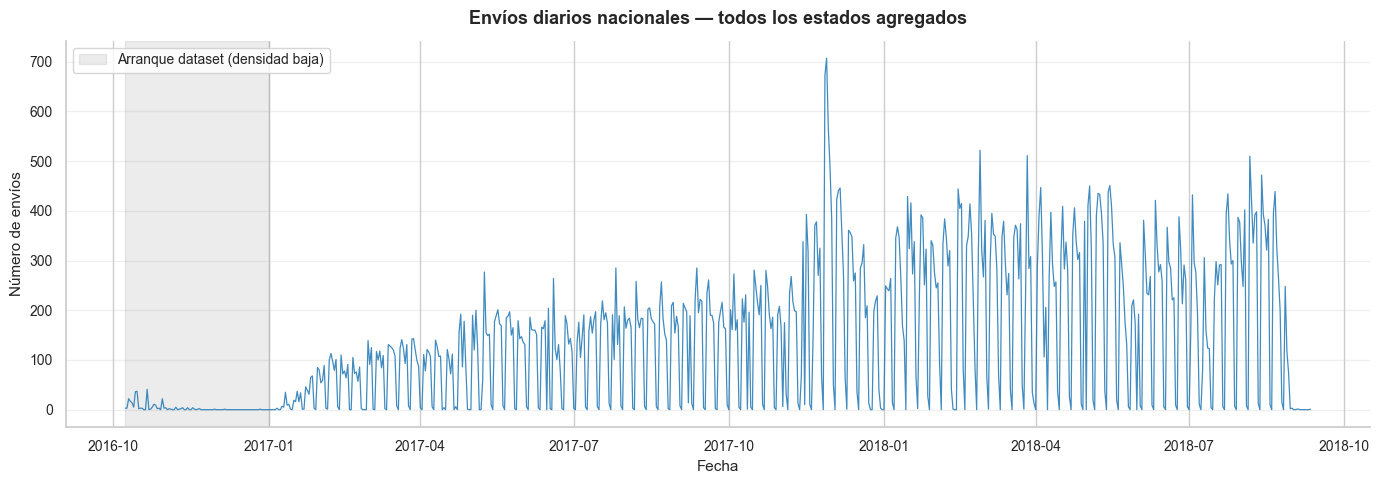


Estadísticas de la serie nacional:
count    704.0
mean     138.6
std      142.8
min        0.0
25%        1.0
50%      111.5
75%      245.5
max      707.0


In [14]:
# Plot: serie temporal nacional
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_national["shipment_date"],
    df_national["n_shipments_total"],
    linewidth=0.9,
    alpha=0.85,
)

ax.set_title("Envíos diarios nacionales — todos los estados agregados", pad=12)
ax.set_xlabel("Fecha")
ax.set_ylabel("Número de envíos")
ax.grid(axis="y", alpha=0.3)

# Sombrear el periodo de arranque (densidad baja sospechosa)
ax.axvspan(
    df_national["shipment_date"].min(),
    pd.Timestamp("2017-01-01"),
    color="grey",
    alpha=0.15,
    label="Arranque dataset (densidad baja)",
)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

# Stats descriptivos
print("\nEstadísticas de la serie nacional:")
print(df_national["n_shipments_total"].describe().round(1).to_string())

In [15]:
# Cuantos días tienen 0 envíos totales? Donde están?
zero_days = df_national[df_national["n_shipments_total"] == 0]
print(f"Días con 0 envíos nacionales: {len(zero_days)}")
print(f"Rango: {zero_days['shipment_date'].min().date()} → {zero_days['shipment_date'].max().date()}")
print(f"\nÚltimo día con 0 envíos: {zero_days['shipment_date'].max().date()}")

# Histograma de envíos diarios por mes
df_national["year_month"] = df_national["shipment_date"].dt.to_period("M")
monthly_summary = (
    df_national.groupby("year_month")
    .agg(
        n_days=("shipment_date", "count"),
        avg_shipments=("n_shipments_total", "mean"),
        total_shipments=("n_shipments_total", "sum"),
    )
    .round(1)
)

print("\nResumen mensual:")
print(monthly_summary.to_string())

Días con 0 envíos nacionales: 157
Rango: 2016-10-19 → 2018-09-10

Último día con 0 envíos: 2018-09-10

Resumen mensual:
            n_days  avg_shipments  total_shipments
year_month                                        
2016-10         24           10.1              242
2016-11         30            1.1               32
2016-12         31            0.1                2
2017-01         31           19.7              612
2017-02         28           54.2             1517
2017-03         31           87.6             2717
2017-04         30           71.4             2141
2017-05         31          119.6             3709
2017-06         30          108.8             3263
2017-07         31          119.7             3710
2017-08         31          139.6             4328
2017-09         30          137.7             4131
2017-10         31          144.6             4482
2017-11         30          221.2             6637
2017-12         31          196.2             6081
2018-01      

In [16]:
# Definir ventana temporal modelable
START_DATE = pd.Timestamp("2017-01-01")
END_DATE = pd.Timestamp("2018-08-31")

# Aplicar el corte
mask = (df["shipment_date"] >= START_DATE) & (df["shipment_date"] <= END_DATE)
df_clean = df[mask].copy()
df_national_clean = df_national[
    (df_national["shipment_date"] >= START_DATE)
    & (df_national["shipment_date"] <= END_DATE)
].copy()

# Stats de la versión limpia
print(f"Periodo modelable: {START_DATE.date()} → {END_DATE.date()}")
print(f"Días en ventana:   {df_national_clean.shape[0]}")
print(f"Envíos totales:    {df_clean['n_shipments'].sum():,}")
print(
    f"% del total original: "
    f"{df_clean['n_shipments'].sum() / df['n_shipments'].sum() * 100:.1f}%"
)

print("\nEstadísticas de la serie nacional (limpia):")
print(df_national_clean["n_shipments_total"].describe().round(1).to_string())

Periodo modelable: 2017-01-01 → 2018-08-31
Días en ventana:   608
Envíos totales:    97,304
% del total original: 99.7%

Estadísticas de la serie nacional (limpia):
count    608.0
mean     160.0
std      142.2
min        0.0
25%        8.0
50%      153.0
75%      267.0
max      707.0


In [17]:
# Hay días con 0 envíos nacionales en el periodo limpio?
zeros_clean = df_national_clean[df_national_clean["n_shipments_total"] == 0]
print(f"Días con 0 envíos nacionales (limpio): {len(zeros_clean)}")

if len(zeros_clean) > 0:
    zeros_clean = zeros_clean.copy()
    zeros_clean["dow"] = zeros_clean["shipment_date"].dt.day_name()
    print("\nDetalle de esos días:")
    print(zeros_clean[["shipment_date", "dow", "n_shipments_total"]].to_string(index=False))

Días con 0 envíos nacionales (limpio): 99

Detalle de esos días:
shipment_date       dow  n_shipments_total
   2017-01-01    Sunday                  0
   2017-01-02    Monday                  0
   2017-01-03   Tuesday                  0
   2017-01-04 Wednesday                  0
   2017-01-05  Thursday                  0
   2017-01-07  Saturday                  0
   2017-01-08    Sunday                  0
   2017-01-15    Sunday                  0
   2017-01-29    Sunday                  0
   2017-02-12    Sunday                  0
   2017-02-18  Saturday                  0
   2017-02-19    Sunday                  0
   2017-02-26    Sunday                  0
   2017-02-27    Monday                  0
   2017-02-28   Tuesday                  0
   2017-03-05    Sunday                  0
   2017-03-12    Sunday                  0
   2017-03-19    Sunday                  0
   2017-03-26    Sunday                  0
   2017-04-02    Sunday                  0
   2017-04-09    Sunday         

In [18]:
import holidays

# Generar feriados nacionales de Brasil para el periodo
br_holidays = holidays.country_holidays(
    "BR",
    years=range(START_DATE.year, END_DATE.year + 1),
)

# Función para clasificar cada día
def classify_day(date: pd.Timestamp) -> str:
    """Return one of: 'sunday', 'holiday', 'business_day'."""
    if date.dayofweek == 6:  # 0=Monday, 6=Sunday
        return "sunday"
    if date.date() in br_holidays:
        return "holiday"
    return "business_day"


# Enriquecer df_national_clean
df_national_clean["day_type"] = df_national_clean["shipment_date"].apply(classify_day)
df_national_clean["is_business_day"] = df_national_clean["day_type"] == "business_day"

# Conteo por tipo de día
print("Composición del periodo modelable:")
print(df_national_clean["day_type"].value_counts().to_string())
print(f"\nTotal: {len(df_national_clean)} días")

# Días hábiles: cuántos tienen 0 envíos? (debería ser MUY raro)
zeros_business = df_national_clean[
    (df_national_clean["is_business_day"]) & (df_national_clean["n_shipments_total"] == 0)
]
print(f"\nDías hábiles con 0 envíos (anomalías): {len(zeros_business)}")
if len(zeros_business) > 0:
    print(zeros_business[["shipment_date", "day_type", "n_shipments_total"]].to_string(index=False))

Composición del periodo modelable:
day_type
business_day    509
sunday           87
holiday          12

Total: 608 días

Días hábiles con 0 envíos (anomalías): 13
shipment_date     day_type  n_shipments_total
   2017-01-02 business_day                  0
   2017-01-03 business_day                  0
   2017-01-04 business_day                  0
   2017-01-05 business_day                  0
   2017-01-07 business_day                  0
   2017-02-18 business_day                  0
   2017-02-27 business_day                  0
   2017-02-28 business_day                  0
   2017-05-06 business_day                  0
   2017-06-15 business_day                  0
   2018-02-12 business_day                  0
   2018-02-13 business_day                  0
   2018-05-31 business_day                  0


In [19]:
from datetime import date


def get_easter(year: int) -> date:
    """Compute Easter Sunday for a given year (Anonymous Gregorian algorithm)."""
    a = year % 19
    b = year // 100
    c = year % 100
    d = b // 4
    e = b % 4
    f = (b + 8) // 25
    g = (b - f + 1) // 3
    h = (19 * a + b - d - g + 15) % 30
    i = c // 4
    k = c % 4
    l = (32 + 2 * e + 2 * i - h - k) % 7
    m = (a + 11 * h + 22 * l) // 451
    month = (h + l - 7 * m + 114) // 31
    day = ((h + l - 7 * m + 114) % 31) + 1
    return date(year, month, day)


def build_br_operational_holidays(years: range) -> set[date]:
    """Brazilian operational holidays = national fixed holidays + Carnival + Corpus Christi.

    Args:
        years: Range of years to compute.

    Returns:
        Set of dates considered non-operational for shipping.
    """
    from datetime import timedelta

    op_holidays: set[date] = set()

    # National fixed holidays
    op_holidays.update(holidays.country_holidays("BR", years=years).keys())

    for year in years:
        easter = get_easter(year)
        # Carnival = 48 and 47 days before Easter (Monday and Tuesday)
        op_holidays.add(easter - timedelta(days=48))
        op_holidays.add(easter - timedelta(days=47))
        # Corpus Christi = 60 days after Easter (Thursday)
        op_holidays.add(easter + timedelta(days=60))

    return op_holidays


# Build operational holiday set
op_holidays = build_br_operational_holidays(range(START_DATE.year, END_DATE.year + 1))
print(f"Total feriados operacionales detectados: {len(op_holidays)}")
print("\nLista ordenada:")
for d in sorted(op_holidays):
    if START_DATE.date() <= d <= END_DATE.date():
        print(f"  {d}  {d.strftime('%A')}")

Total feriados operacionales detectados: 24

Lista ordenada:
  2017-01-01  Sunday
  2017-02-27  Monday
  2017-02-28  Tuesday
  2017-04-14  Friday
  2017-04-21  Friday
  2017-05-01  Monday
  2017-06-15  Thursday
  2017-09-07  Thursday
  2017-10-12  Thursday
  2017-11-02  Thursday
  2017-11-15  Wednesday
  2017-12-25  Monday
  2018-01-01  Monday
  2018-02-12  Monday
  2018-02-13  Tuesday
  2018-03-30  Friday
  2018-04-21  Saturday
  2018-05-01  Tuesday
  2018-05-31  Thursday


In [20]:
# Reclasificar usando el calendario operacional completo
def classify_day_v2(date_ts: pd.Timestamp) -> str:
    """Return one of: 'sunday', 'holiday', 'business_day'."""
    if date_ts.dayofweek == 6:
        return "sunday"
    if date_ts.date() in op_holidays:
        return "holiday"
    return "business_day"


df_national_clean["day_type"] = df_national_clean["shipment_date"].apply(classify_day_v2)
df_national_clean["is_business_day"] = df_national_clean["day_type"] == "business_day"

# Recomputar composición
print("Composición después de reclasificación:")
print(df_national_clean["day_type"].value_counts().to_string())

# Anomalías remanentes (días hábiles con 0)
zeros_business_v2 = df_national_clean[
    (df_national_clean["is_business_day"]) & (df_national_clean["n_shipments_total"] == 0)
]
print(f"\nDías hábiles con 0 envíos (después de reclasificar): {len(zeros_business_v2)}")
if len(zeros_business_v2) > 0:
    print("Detalle:")
    print(
        zeros_business_v2[["shipment_date", "day_type", "n_shipments_total"]].to_string(index=False)
    )

# Mismo análisis para df granular (por estado)
df_clean["day_type"] = df_clean["shipment_date"].apply(classify_day_v2)
df_clean["is_business_day"] = df_clean["day_type"] == "business_day"

Composición después de reclasificación:
day_type
business_day    503
sunday           87
holiday          18

Días hábiles con 0 envíos (después de reclasificar): 7
Detalle:
shipment_date     day_type  n_shipments_total
   2017-01-02 business_day                  0
   2017-01-03 business_day                  0
   2017-01-04 business_day                  0
   2017-01-05 business_day                  0
   2017-01-07 business_day                  0
   2017-02-18 business_day                  0
   2017-05-06 business_day                  0


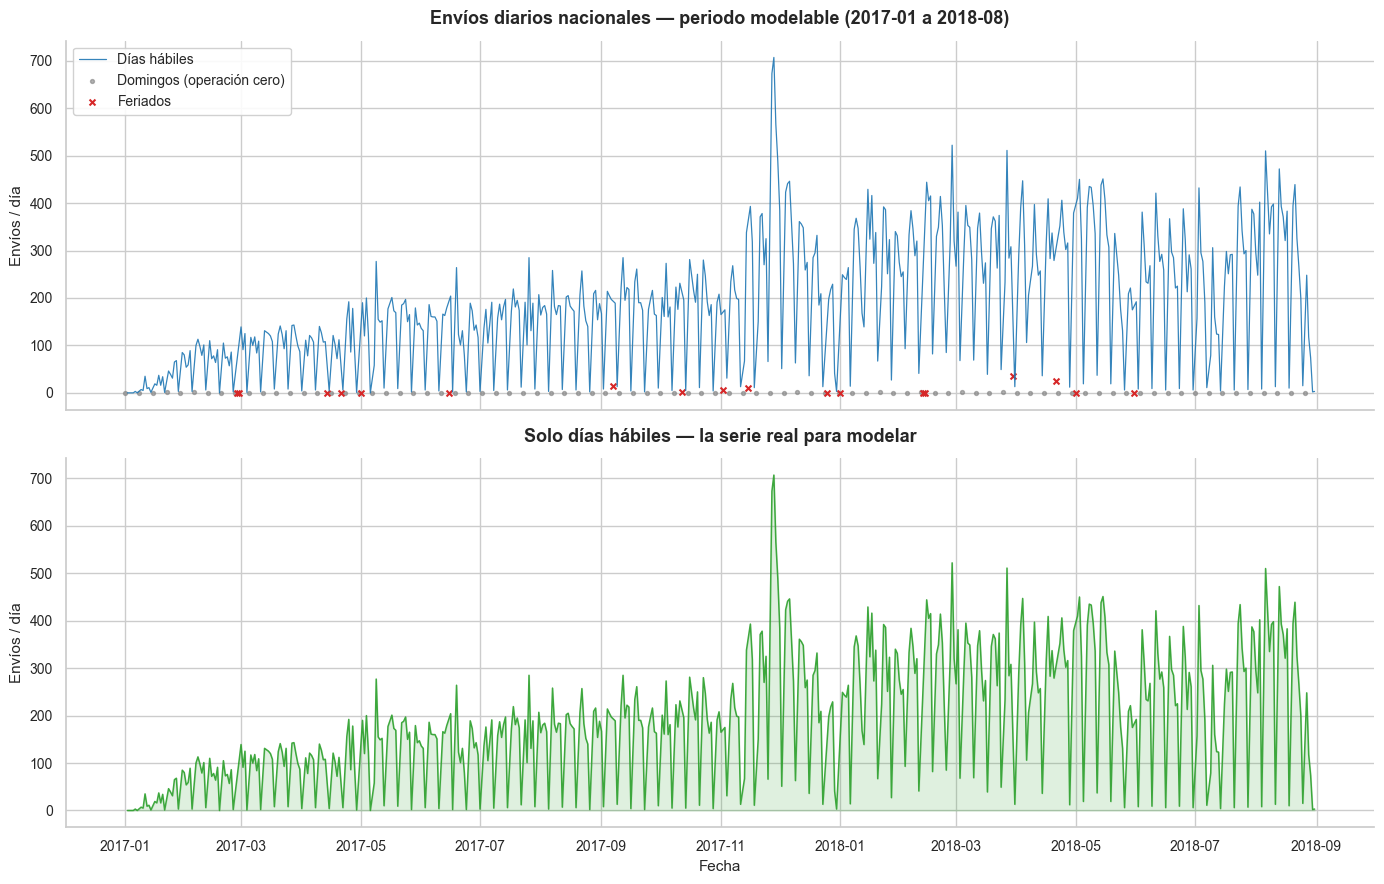


Estadísticas finales (solo días hábiles):
count    503.0
mean     193.2
std      134.4
min        0.0
25%       86.0
50%      185.0
75%      291.0
max      707.0


In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# --- Panel superior: serie completa con domingos visibles ---
ax = axes[0]
business = df_national_clean[df_national_clean["is_business_day"]]
sundays = df_national_clean[df_national_clean["day_type"] == "sunday"]
hols = df_national_clean[df_national_clean["day_type"] == "holiday"]

ax.plot(
    business["shipment_date"],
    business["n_shipments_total"],
    color=PALETTE[0],
    linewidth=0.9,
    alpha=0.9,
    label="Días hábiles",
)
ax.scatter(
    sundays["shipment_date"],
    sundays["n_shipments_total"],
    color="grey",
    s=8,
    alpha=0.6,
    label="Domingos (operación cero)",
)
ax.scatter(
    hols["shipment_date"],
    hols["n_shipments_total"],
    color=PALETTE[3],
    s=18,
    marker="x",
    label="Feriados",
)
ax.set_title(
    "Envíos diarios nacionales — periodo modelable (2017-01 a 2018-08)",
    pad=12,
)
ax.set_ylabel("Envíos / día")
ax.legend(loc="upper left", framealpha=0.9)

# --- Panel inferior: solo días hábiles ---
ax = axes[1]
ax.plot(
    business["shipment_date"],
    business["n_shipments_total"],
    color=PALETTE[2],
    linewidth=1.1,
    alpha=0.9,
)
ax.fill_between(
    business["shipment_date"],
    business["n_shipments_total"],
    alpha=0.15,
    color=PALETTE[2],
)
ax.set_title("Solo días hábiles — la serie real para modelar", pad=12)
ax.set_xlabel("Fecha")
ax.set_ylabel("Envíos / día")

plt.tight_layout()
plt.show()

# Stats finales — solo días hábiles
print("\nEstadísticas finales (solo días hábiles):")
print(business["n_shipments_total"].describe().round(1).to_string())

Estadísticas por día de la semana (días hábiles, excluye feriados):
                   avg_shipments  median_shipments  std_shipments  n_days
dow_num dow_name                                                         
0       Monday             241.5             222.0          126.0      82
1       Tuesday            258.9             249.0          135.2      84
2       Wednesday          229.8             214.5          118.8      86
3       Thursday           209.1             193.0          105.5      82
4       Friday             202.6             190.0          100.0      84
5       Saturday            20.3               8.0           32.7      85


/var/folders/n4/hklslsrn5t91cccgjf28xl2c0000gn/T/ipykernel_1251/3507824542.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


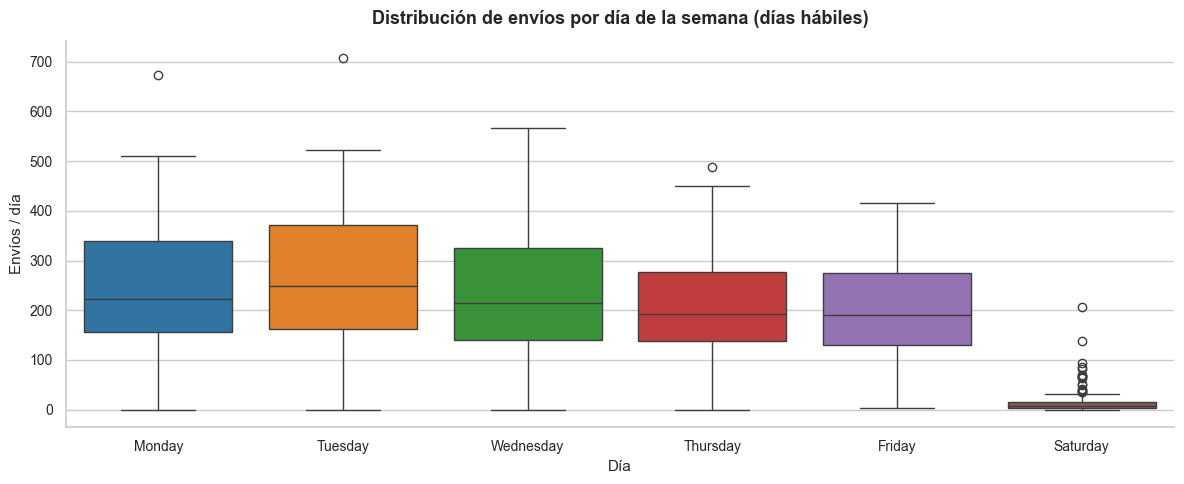

In [22]:
# Análisis por día de la semana (solo días hábiles)
business_only = df_national_clean[df_national_clean["is_business_day"]].copy()
business_only["dow_num"] = business_only["shipment_date"].dt.dayofweek  # 0=Mon
business_only["dow_name"] = business_only["shipment_date"].dt.day_name()

dow_stats = (
    business_only.groupby(["dow_num", "dow_name"])
    .agg(
        avg_shipments=("n_shipments_total", "mean"),
        median_shipments=("n_shipments_total", "median"),
        std_shipments=("n_shipments_total", "std"),
        n_days=("shipment_date", "count"),
    )
    .round(1)
    .sort_index()
)

print("Estadísticas por día de la semana (días hábiles, excluye feriados):")
print(dow_stats.to_string())

# Plot: boxplot por día de la semana
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=business_only,
    x="dow_name",
    y="n_shipments_total",
    order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"],
    ax=ax,
    palette=PALETTE[:6],
)
ax.set_title("Distribución de envíos por día de la semana (días hábiles)", pad=12)
ax.set_xlabel("Día")
ax.set_ylabel("Envíos / día")
plt.tight_layout()
plt.show()

In [23]:
# Reclasificación final: cuatro categorías de día
def classify_day_v3(date_ts: pd.Timestamp) -> str:
    """Classify a date for shipping operations.

    Returns:
        One of:
          - 'sunday'       : no operation by design
          - 'holiday'      : national or operational holiday (no operation)
          - 'saturday'     : reduced operation (~8% of weekday volume)
          - 'business_day' : full operation (Monday-Friday non-holiday)
    """
    if date_ts.dayofweek == 6:
        return "sunday"
    if date_ts.date() in op_holidays:
        return "holiday"
    if date_ts.dayofweek == 5:
        return "saturday"
    return "business_day"


# Aplicar a ambos DataFrames
df_national_clean["day_type"] = df_national_clean["shipment_date"].apply(classify_day_v3)
df_national_clean["is_business_day"] = df_national_clean["day_type"] == "business_day"
df_national_clean["is_saturday"] = df_national_clean["day_type"] == "saturday"
df_national_clean["is_operational"] = df_national_clean["day_type"].isin(
    ["business_day", "saturday"]
)

df_clean["day_type"] = df_clean["shipment_date"].apply(classify_day_v3)
df_clean["is_business_day"] = df_clean["day_type"] == "business_day"
df_clean["is_saturday"] = df_clean["day_type"] == "saturday"
df_clean["is_operational"] = df_clean["day_type"].isin(["business_day", "saturday"])

# Composición final
print("Composición final del periodo modelable:")
print(df_national_clean["day_type"].value_counts().to_string())
print(f"\nTotal: {len(df_national_clean)} días")

# Stats por categoría
print("\nEstadísticas por tipo de día:")
stats_by_type = (
    df_national_clean.groupby("day_type")
    .agg(
        n_days=("shipment_date", "count"),
        avg_shipments=("n_shipments_total", "mean"),
        median_shipments=("n_shipments_total", "median"),
        min_shipments=("n_shipments_total", "min"),
        max_shipments=("n_shipments_total", "max"),
    )
    .round(1)
    .sort_values("avg_shipments", ascending=False)
)
print(stats_by_type.to_string())

Composición final del periodo modelable:
day_type
business_day    418
sunday           87
saturday         85
holiday          18

Total: 608 días

Estadísticas por tipo de día:
              n_days  avg_shipments  median_shipments  min_shipments  max_shipments
day_type                                                                           
business_day     418          228.4             207.5              0            707
saturday          85           20.3               8.0              0            206
holiday           18            5.1               0.0              0             35
sunday            87            0.1               0.0              0              2
